In [ ]:
import sys

print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [ ]:
from tensorflow import keras

print(keras.__version__)

3.13.2


In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully!")

All libraries imported successfully!


In [15]:
from google.colab import files

uploaded = files.upload()

Saving dataset.csv to dataset.csv


In [16]:
import os

print(os.listdir('/content'))

['.config', 'dataset.csv', 'sample_data']


In [17]:
df = pd.read_csv('/content/dataset.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# Load dataset
df = pd.read_csv("dataset.csv")

# Display first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
# Remove customerID column (not useful)
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove missing values
df.dropna(inplace=True)

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [21]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model_adam = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model_adam.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_adam = model_adam.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6838 - loss: 0.6434 - val_accuracy: 0.7662 - val_loss: 0.5179
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7564 - loss: 0.5158 - val_accuracy: 0.7849 - val_loss: 0.4456
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7758 - loss: 0.4847 - val_accuracy: 0.7902 - val_loss: 0.4324
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7767 - loss: 0.4719 - val_accuracy: 0.7920 - val_loss: 0.4268
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7791 - loss: 0.4673 - val_accuracy: 0.7929 - val_loss: 0.4208
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7916 - loss: 0.4400 - val_accuracy: 0.7982 - val_loss: 0.4161
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7911 - loss: 0.4430 - val_accuracy: 0.8018 - val_loss: 0.4174
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7927 - loss: 0.4376 - val_accuracy: 0.80

In [25]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_adam = (model_adam.predict(X_test) > 0.5).astype(int)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_adam))

print("\nClassification Report")
print(classification_report(y_test, y_pred_adam))

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Confusion Matrix
[[899 134]
 [174 200]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1033
           1       0.60      0.53      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



In [26]:
from tensorflow.keras.optimizers import SGD

model_sgd = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_sgd = model_sgd.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6329 - loss: 0.6697 - val_accuracy: 0.7609 - val_loss: 0.5125
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7200 - loss: 0.5512 - val_accuracy: 0.7716 - val_loss: 0.4692
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7620 - loss: 0.5024 - val_accuracy: 0.7813 - val_loss: 0.4456
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7653 - loss: 0.4892 - val_accuracy: 0.7849 - val_loss: 0.4338
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7724 - loss: 0.4743 - val_accuracy: 0.7911 - val_loss: 0.4282


In [27]:
y_pred_sgd = (model_sgd.predict(X_test) > 0.5).astype(int)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_sgd))

print("\nClassification Report")
print(classification_report(y_test, y_pred_sgd))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Confusion Matrix
[[875 158]
 [191 183]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1033
           1       0.54      0.49      0.51       374

    accuracy                           0.75      1407
   macro avg       0.68      0.67      0.67      1407
weighted avg       0.75      0.75      0.75      1407



In [28]:
adam_loss, adam_acc = model_adam.evaluate(X_test, y_test, verbose=0)
sgd_loss, sgd_acc = model_sgd.evaluate(X_test, y_test, verbose=0)

print("Adam Accuracy :", round(adam_acc * 100, 2), "%")
print("SGD Accuracy  :", round(sgd_acc * 100, 2), "%")

Adam Accuracy : 78.11 %
SGD Accuracy  : 75.2 %


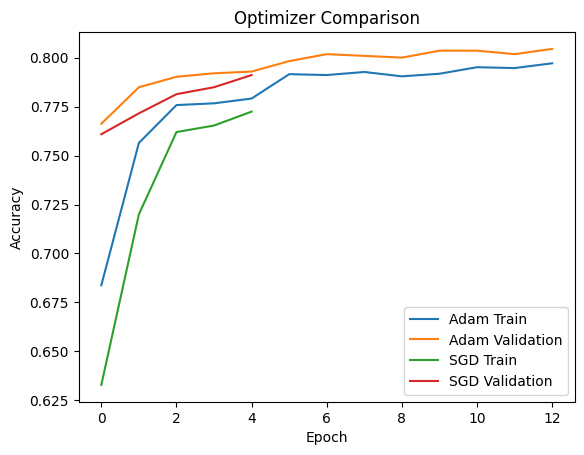

In [29]:
import matplotlib.pyplot as plt

plt.plot(history_adam.history["accuracy"], label="Adam Train")
plt.plot(history_adam.history["val_accuracy"], label="Adam Validation")

plt.plot(history_sgd.history["accuracy"], label="SGD Train")
plt.plot(history_sgd.history["val_accuracy"], label="SGD Validation")

plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()